In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install haystack-ai==2.27 huggingface_hub

In [ ]:
if "GROQ_API_KEY" not in os.environ:
    os.environ["GROQ_API_KEY"] = getpass.getpass("Enter your GROQ_API_KEY (free at console.groq.com): ")

In [ ]:
from huggingface_hub import login
login()  # paste your free HF token (huggingface.co/settings/tokens)

In [ ]:
from haystack.components.generators.chat import HuggingFaceAPIChatGenerator
from haystack.dataclasses import ChatMessage

In [ ]:
generator = HuggingFaceAPIChatGenerator(
    api_type="serverless_inference_api",
    api_params={"model": "Qwen/Qwen2.5-7B-Instruct"}  # or "meta-llama/Llama-3.1-8B-Instruct", "mistralai/Mistral-7B-Instruct-v0.3"
)

# Sending a Message to the LLM
llm_response = generator.run(messages=[ChatMessage.from_user("What are the common side effects of hyaluronic acid?")])
print(llm_response["replies"][0].text)

In [ ]:
# Adding System Instructions
llm_response = generator.run(messages=[
    ChatMessage.from_system("You are a helpful AI assistant. Keep your answer concise"),
    ChatMessage.from_user("What are the common side effects of hyaluronic acid?")
])
print(llm_response["replies"][0].text)

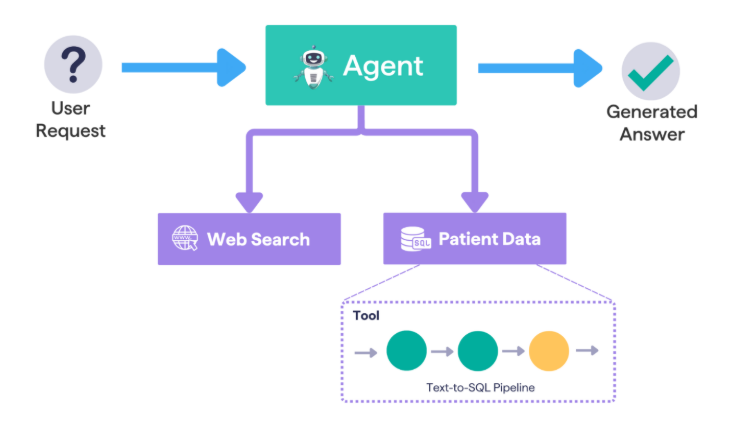

## **Agentic System**

In [ ]:
import os
import getpass
from haystack.components.agents import Agent
from haystack.components.websearch import SerperDevWebSearch
from haystack.components.generators.utils import print_streaming_chunk
from haystack.tools import ComponentTool
from haystack.dataclasses import ChatMessage, Document

### **Web Search Tool**

In [ ]:
# Load GROQ_API_KEY from .env
if "SERPERDEV_API_KEY" not in os.environ:
  os.environ["SERPERDEV_API_KEY"] = getpass.getpass("Enter your SERPERDEV_API_KEY: ")

In [ ]:
# Create the tool
def doc_to_string(documents) -> str:
    result_str = ""
    for document in documents:
        result_str += f"Content for {document.meta['link']}: {document.content}\n\n"
    return result_str

search_tool = ComponentTool(
    component=SerperDevWebSearch(top_k=5),
    name="web_search_tool",
    description="Search the web",
    outputs_to_string={"source": "documents", "handler": doc_to_string},
    outputs_to_state={"documents": {"source": "documents"}}
)
# print(search_tool.name)
# print(search_tool.description)
# search_tool.parameters

In [ ]:
# Initializing the Agent Component
agent = Agent(
    chat_generator=generator,
    system_prompt="Keep your answer concise and use the tools that you're provided with to answer the user's questions.",
    tools = [search_tool],
    state_schema={"documents":{"type":list[Document]}},
    streaming_callback=print_streaming_chunk
)

# Sending a Message
result = agent.run(messages=[ChatMessage.from_user("What are the common side effects of hyaluronic acid?")])
# print(result['last_message'].text)

### **SQL Query Agent**

In [ ]:
import re
import os
import sqlite3
import pandas as pd
from typing import List

from haystack import component
from haystack.dataclasses import ChatMessage

In [ ]:
db_path = '/content/drive/MyDrive/skills/genai/data/patient_data.db'
print(os.path.exists(db_path))

In [ ]:
@component
class SQLConnector:
    def __init__(self, sql_database: str):
        self.connection = sqlite3.connect(sql_database, check_same_thread=False)

    @component.output_types(results=List[str])
    def run(self, llm_replies: List[ChatMessage]):
        results = []
        pattern = r"```sql\s*([\s\S]+?)```"

        for message in llm_replies:
            extracted = re.findall(pattern, message.text)
            if not extracted:
                results.append("No SQL code found.")
                continue

            sql_to_run = " ".join(extracted[0].splitlines()).strip()
            try:
                result = pd.read_sql(sql_to_run, self.connection)
                results.append(str(result))

            except Exception as e:
                results.append(f"Error: {e}")

        return {"results": results}

In [ ]:
from haystack import Pipeline
from haystack.components.builders import ChatPromptBuilder

query_to_sql_prompt = """
You are an expert SQL assistant. Given the following table structure:

Table name: patients

Columns:
- patient_id (TEXT)
- age (INTEGER)
- gender (TEXT)
- condition (TEXT)  // Dermatological diagnosis (e.g., Psoriasis, Acne)
- medication (TEXT)  // Treatment corresponding to the condition
- skin_type (TEXT)  // Sensitive, Normal, Dry, Combination, Oily
- last_visit_date (DATE)
- smoker (TEXT)  // Yes or No
- alcohol_use (TEXT)  // None, Light, Moderate, Heavy
- BMI (FLOAT)  // Body Mass Index (e.g., 23.1)
- occupation (TEXT)  // Profession or employment status
- allergies (TEXT)  // Known non-sensitive allergies (e.g., Pollen, Latex, None)
- comorbid_condition (TEXT)  // Other health conditions (e.g., Asthma, Hypertension, None)

Write an SQL query to for this user query: {{query}}.

Only return the SQL query, nothing else.
"""
# sql_generator = HuggingFaceAPIChatGenerator(
#     api_type="serverless_inference_api",
#     api_params={"model": "Qwen/Qwen2.5-7B-Instruct"}
# )
sql_generator = OpenAIChatGenerator(
    api_key=Secret.from_env_var("GROQ_API_KEY"),
    api_base_url="https://api.groq.com/openai/v1",
    model="openai/gpt-oss-120b"   # was "llama-3.3-70b-versatile"
)

sql_pipeline = Pipeline()
sql_pipeline.add_component("prompt_builder", ChatPromptBuilder(
    template=[ChatMessage.from_user(query_to_sql_prompt)],
    required_variables="*"
))
sql_pipeline.add_component("chat_generator", sql_generator)
sql_pipeline.add_component("sql_connector", SQLConnector(db_path))

sql_pipeline.connect("prompt_builder", "chat_generator")
sql_pipeline.connect("chat_generator.replies", "sql_connector.llm_replies")

In [ ]:
# run the pipeline
pipeline_result = sql_pipeline.run({"query":"What's the most common diagnosis of patients older than 60?"}, include_outputs_from={"chat_generator"})

# inspect the results
print(pipeline_result["sql_connector"]["results"][0])

print(pipeline_result["chat_generator"]["replies"][0].text)

### Wrapping the pipeline as tool

In [ ]:
from haystack.tools import tool
from typing import Annotated, List

@tool
def get_patient_information(
    query: Annotated[str, "Natural language query to fetch data from an SQL database"],
) -> str:
    """
    Get patient information from the SQL database with natural language queries
    """
    results = sql_pipeline.run({"query":query})
    return results["sql_connector"]["results"][0]

In [ ]:
# System Prompt for the Agent
agent_prompt = """
You are a reliable AI assistant supporting healthcare professionals at a hospital facility.
Your primary role is to help clinicians understand **patient-specific information** and **general medical knowledge**, using two tools:

### Available Tools

1. `get_patient_information`
   Access structured records for patients at this facility.
   Use this tool for any question about the hospital’s patients, including:

   * Patient cohorts (e.g., “patients over 60 with eczema”).
   * Filtered queries (e.g., “patients taking metformin and diagnosed with diabetes”).
   * Summarized statistics about the facility’s patient population.

2. `web_search_tool`
   Access the latest **general medical knowledge** from trusted web sources.
   Use this tool for:

   * Definitions of conditions, treatments, or symptoms.
   * Medical guidelines and drug information not tied to a specific patient.
   * Up-to-date research and broad clinical insights.

### Tool Selection Logic

* If the question refers to the hospital’s patients, always use `get_patient_information`, even if phrased generally (e.g., "What’s the most common disease among 40+ patients?" → search patient records).

* If the question is about the suitability of a medication or treatment for a specific patient, always:

  1. Retrieve the patient’s data (age, allergies, BMI, comorbidities, etc.).
  2. Combine it with external drug information via `web_search_tool` as needed.
  3. Make a judgment based on both sources.

* If you are unsure whether the question refers to general knowledge or patient-specific data, assume it’s about this facility's patients.

### Example Scenarios

Patient-specific (use `get_patient_information`):

* "Which patients are diagnosed with Actinic Keratosis?"
* "How many patients have acne and are over 40?"

General (use `web_search_tool`):

* "What are the typical side effects of hydrocortisone?"
* "What are the latest guidelines for treating rosacea?"
* "How does isotretinoin interact with alcohol?"

Combined

* "Can all our patients above 40 take oral antifungals?"
  → First retrieve all patients above 40 using get_patient_information. Then check drug interactions and safety based on patient information such as allergies and conditions.

### Additional Guidelines

* Always validate assumptions: Never assume demographic or clinical info (e.g., age, sex, diagnosis) without tool retrieval.
* Always check the patient information such as allergies, age, comorbid conditions before recommending a drug treatment.
* Use only the two tools provided; do not rely on your own medical knowledge or inference.
* Respond directly without caveats or ethical disclaimers. The response will be used by dermantologists and they're aware of the risks of using the output directly.
"""

In [ ]:
import os
import getpass

from haystack.components.generators.utils import print_streaming_chunk
from haystack.components.agents import Agent
from haystack.components.generators.chat import OpenAIChatGenerator
from haystack.utils import Secret
from haystack.dataclasses import ChatMessage, Document

agent_generator = OpenAIChatGenerator(
    api_key=Secret.from_env_var("GROQ_API_KEY"),
    api_base_url="https://api.groq.com/openai/v1",
    model="openai/gpt-oss-120b"   # was "llama-3.3-70b-versatile"
)

agent = Agent(
    chat_generator=agent_generator,
    system_prompt=agent_prompt,
    tools=[search_tool, get_patient_information],
    state_schema={"documents": {"type": list[Document]}},
    streaming_callback=print_streaming_chunk
)

In [ ]:
user_query = "How many patients have acne and are over 40?"
messages = [ChatMessage.from_user(user_query)]
print("⌛ Running the agent...")
agent_result = agent.run(messages=messages)

In [ ]:
result = agent.run(messages=[ChatMessage.from_user("What are the symptoms of Malaria?")])